# Eksperimen Lanjutan: Mencari Batas Model — Kelompok 3

**Mata Kuliah:** Machine Learning (Kelas C) — Bapak Adi Purnawan

**Judul:** Prediksi Risiko Stroke Menggunakan Logistic Regression dan Gradient Boosting dengan Interpretasi Explainable AI

**Anggota:** Deliana Br Manalu (2305551036) · Ravi Arnan Irianto (2305551076) · Ezza Putra Wibawa (2305551144) · Devin (2305551173)

---

Notebook `05` sudah menghasilkan model yang bekerja. Notebook ini bertanya lebih jauh:
**apakah bisa dibuat lebih baik lagi?**

Tujuh gagasan diuji satu per satu — rekayasa fitur berbasis pengetahuan medis, tujuh
cara menyeimbangkan kelas, penggabungan model, model-model yang lebih kuat, kalibrasi
probabilitas, dan pemilihan ambang berbasis biaya klinis.

**Sebagian besar gagasan itu gagal.** Notebook ini melaporkan kegagalannya apa adanya,
karena mengetahui apa yang *tidak* berhasil sama berharganya — dan jauh lebih jarang
ditulis orang.


## 0. Masalah Alat Ukur

Sebelum menguji apa pun, satu hal harus dibereskan dulu: **seberapa besar derau
pengukuran kita?**

Data kami hanya punya 249 kasus stroke. Dengan 5-fold cross-validation, tiap lipatan
uji cuma berisi sekitar 50 kasus. Satu-dua pasien yang kebetulan sulit sudah cukup
menggoyang angkanya.

Kalau derau ini tidak diukur, kita akan merayakan "peningkatan" yang sebenarnya cuma
lemparan dadu.

In [1]:
!pip install -q imbalanced-learn 2>/dev/null || true

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (GradientBoostingClassifier, HistGradientBoostingClassifier,
                              ExtraTreesClassifier, RandomForestClassifier, VotingClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, recall_score, precision_score
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline as PipaImb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
SEED = 42

FITUR_IMP = ["age", "hypertension", "heart_disease", "avg_glucose_level",
             "gender", "ever_married", "work_type", "Residence_type", "smoking_status"]


def muat(mentah=False):
    """Preprocessing identik notebook 04."""
    url = ("https://raw.githubusercontent.com/ray-project/raydp/master/"
           "tutorials/dataset/healthcare-dataset-stroke-data.csv")
    d = pd.read_csv(url).drop(columns=["id"])
    d = d[d.gender != "Other"].copy()
    kosong = d.bmi.isna()
    if kosong.any():
        latih = d[~kosong]
        X_l = pd.get_dummies(latih[FITUR_IMP], drop_first=True)
        m = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=SEED)).fit(X_l, latih.bmi)
        X_k = pd.get_dummies(d[kosong][FITUR_IMP], drop_first=True).reindex(
            columns=X_l.columns, fill_value=0)
        d.loc[kosong, "bmi"] = m.predict(X_k)
    if mentah:
        return d
    return pd.get_dummies(d.drop(columns=["stroke"]), drop_first=True), d.stroke


ACUAN = lambda: make_pipeline(
    StandardScaler(), LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                         max_iter=5000, random_state=SEED))

X, y = muat()
mentah = muat(mentah=True)
print(f"Data: {X.shape[0]} baris, {X.shape[1]} fitur, positif {y.sum()} ({y.mean()*100:.2f}%)")

Data: 5109 baris, 15 fitur, positif 249 (4.87%)


### Seberapa besar deraunya?

In [3]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)
s = cross_validate(ACUAN(), X, y, cv=cv, scoring=["roc_auc", "average_precision"], n_jobs=-1)

print(f"AUC : {s['test_roc_auc'].mean():.4f} ± {s['test_roc_auc'].std():.4f}")
print(f"AP  : {s['test_average_precision'].mean():.4f} ± {s['test_average_precision'].std():.4f}")
print()
print("Simpangan baku AUC 0,018 itu BESAR. Kalau kita membandingkan dua model lewat")
print("rata-rata masing-masing, peningkatan sekecil 0,01 akan tenggelam dalam derau.")
print()
print("Catatan: AP (average precision) lebih tepat daripada ROC-AUC untuk kejadian")
print("langka, karena tidak dibesar-besarkan oleh 95% kelas negatif yang mudah ditebak.")

AUC : 0.8409 ± 0.0180
AP  : 0.2024 ± 0.0328

Simpangan baku AUC 0,018 itu BESAR. Kalau kita membandingkan dua model lewat
rata-rata masing-masing, peningkatan sekecil 0,01 akan tenggelam dalam derau.

Catatan: AP (average precision) lebih tepat daripada ROC-AUC untuk kejadian
langka, karena tidak dibesar-besarkan oleh 95% kelas negatif yang mudah ditebak.


### Jalan keluar: uji berpasangan

Kuncinya: bandingkan dua model pada **lipatan yang persis sama**, lalu ukur simpangan
baku dari **selisihnya**, bukan dari masing-masing.

Derau yang berasal dari "lipatan ini kebetulan sulit" akan hilang, karena dialami
kedua model sekaligus. Yang tersisa hanyalah perbedaan yang benar-benar berasal dari
modelnya.

In [4]:
def skor_lipatan(model, X, y, cv):
    s = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "average_precision"], n_jobs=-1)
    return s["test_roc_auc"], s["test_average_precision"]


def banding(kandidat, nama, X_kandidat=None, acuan=None, cv=cv):
    """Uji berpasangan terhadap model acuan. 'Nyata' berarti selisihnya lebih dari
    dua galat baku dari nol -- di bawah itu, belum bisa disebut peningkatan."""
    acuan = acuan or ACUAN()
    Xk = X if X_kandidat is None else X_kandidat

    auc_a, ap_a = skor_lipatan(acuan, X, y, cv)
    auc_k, ap_k = skor_lipatan(kandidat, Xk, y, cv)

    h = {"Gagasan": nama}
    for label, a, k in [("AUC", auc_a, auc_k), ("AP", ap_a, ap_k)]:
        d = k - a
        se = d.std(ddof=1) / np.sqrt(len(d))
        h[f"{label} acuan"] = round(a.mean(), 4)
        h[f"{label} baru"] = round(k.mean(), 4)
        h[f"Δ{label}"] = round(d.mean(), 4)
        h[f"±{label}"] = round(se, 4)
        h[f"{label} nyata?"] = "YA" if abs(d.mean()) > 2 * se else "tidak"
    return h

### Memeriksa alatnya sendiri

Sebelum dipakai, alat ukur harus diuji dulu: apakah ia mendeteksi perbedaan yang
memang ada, dan apakah ia diam ketika tidak ada perbedaan?

In [5]:
uji_alat = [
    banding(DummyClassifier(strategy="stratified", random_state=SEED),
            "Model acak — SEHARUSNYA terdeteksi nyata"),
    banding(make_pipeline(StandardScaler(),
                          LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                             max_iter=5000, random_state=SEED + 1)),
            "Model sama, seed beda — SEHARUSNYA tidak nyata"),
]
pd.DataFrame(uji_alat)[["Gagasan", "ΔAUC", "±AUC", "AUC nyata?"]]

,Gagasan,ΔAUC,±AUC,AUC nyata?
0,Model acak — SEHARUSNYA terdeteksi nyata,-0.3414,0.0037,YA
1,"Model sama, seed beda — SEHARUSNYA tidak nyata",-0.0000,0.0000,tidak


Alat ukurnya lulus: menangkap perbedaan yang nyata, dan tidak mengarang perbedaan
yang tidak ada. Galat baku selisih turun ke sekitar 0,004 — sekitar **lima kali lebih
peka** daripada membandingkan rata-rata biasa.

Sekarang kita bisa menguji gagasan-gagasan sungguhan.

## Eksperimen 1 — Rekayasa Fitur Berbasis Pengetahuan Medis

Ambang klinis yang nyata dipakai, bukan angka karangan: batas diabetes menurut ADA
(126 mg/dL), kategori BMI menurut WHO, dan hitungan penyakit penyerta seperti pada
skoring risiko di praktik klinis.

In [6]:
def tambah(kolom):
    return pd.concat([X, pd.DataFrame(kolom, index=X.index)], axis=1)


GAGASAN_FITUR = {
    "Kategori glukosa (ADA)": {"glukosa_kat": np.digitize(mentah.avg_glucose_level, [100, 126])},
    "Kategori BMI (WHO)": {"bmi_kat": np.digitize(mentah.bmi, [18.5, 25, 30])},
    "Usia kuadrat": {"usia2": mentah.age ** 2},
    "Penanda lansia (>=60)": {"lansia": (mentah.age >= 60).astype(int)},
    "Usia × hipertensi": {"usia_x_ht": mentah.age * mentah.hypertension},
    "Usia × penyakit jantung": {"usia_x_pj": mentah.age * mentah.heart_disease},
    "Jumlah faktor risiko": {"n_risiko": (
        mentah.hypertension + mentah.heart_disease
        + (mentah.avg_glucose_level >= 126).astype(int)
        + (mentah.bmi >= 30).astype(int)
        + mentah.smoking_status.isin(["smokes", "formerly smoked"]).astype(int))},
}

hasil_fitur = [banding(ACUAN(), nama, X_kandidat=tambah(kol))
               for nama, kol in GAGASAN_FITUR.items()]

semua = {}
for kol in GAGASAN_FITUR.values():
    semua.update(kol)
hasil_fitur.append(banding(ACUAN(), "SEMUA digabung", X_kandidat=tambah(semua)))

pd.DataFrame(hasil_fitur)[["Gagasan", "ΔAUC", "±AUC", "AUC nyata?",
                           "ΔAP", "±AP", "AP nyata?"]]

,Gagasan,ΔAUC,±AUC,AUC nyata?,ΔAP,±AP,AP nyata?
0,Kategori glukosa (ADA),-0.0002,0.0002,tidak,-0.0005,0.0010,tidak
1,Kategori BMI (WHO),-0.0001,0.0001,tidak,-0.0002,0.0002,tidak
2,Usia kuadrat,-0.0001,0.0002,tidak,0.0016,0.0008,YA
3,Penanda lansia (>=60),-0.0000,0.0000,tidak,-0.0000,0.0000,tidak
4,Usia × hipertensi,-0.0003,0.0001,YA,-0.0006,0.0003,YA
5,Usia × penyakit jantung,0.0000,0.0000,tidak,0.0000,0.0000,tidak
6,Jumlah faktor risiko,-0.0001,0.0002,tidak,0.0001,0.0011,tidak
7,SEMUA digabung,-0.0002,0.0004,tidak,-0.0018,0.0013,tidak


### Hasil: gagal

Tidak satu pun gagasan memberi peningkatan yang berarti. Usia kuadrat lolos uji
statistik, tetapi besarnya hanya sekitar +0,002 AP — sekitar 1% perbaikan relatif,
yang tidak akan mengubah satu pun keputusan klinis.

Menggabungkan semuanya justru **menurunkan** hasil.

**Pelajaran pertama:** *nyata secara statistik* dan *berarti secara praktis* adalah dua
hal berbeda. Dengan 125 lipatan, perbedaan sekecil apa pun bisa lolos uji statistik.
Yang harus ditanyakan berikutnya: apakah besarnya cukup untuk mengubah keputusan?

**Mengapa gagal?** Logistic Regression dengan penalti L1 sudah memangkas fitur yang
tidak berguna, dan Gradient Boosting sudah menangkap hubungan tak-linear serta
interaksi dengan sendirinya. Fitur turunan buatan tangan hanya mengulang apa yang
sudah ditemukan model.

## Eksperimen 2 — Tujuh Cara Menyeimbangkan Kelas

Notebook `02` sudah menunjukkan SMOTE tidak lebih baik daripada menggeser ambang.
Tapi mungkin varian SMOTE yang lain lebih baik? Kami uji semuanya.

In [7]:
LR = lambda: LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                max_iter=5000, random_state=SEED)

CARA_SEIMBANG = {
    "class_weight='balanced'": make_pipeline(
        StandardScaler(), LogisticRegression(C=0.1, penalty="l1", solver="liblinear",
                                             max_iter=5000, class_weight="balanced",
                                             random_state=SEED)),
    "SMOTE": PipaImb([("s", StandardScaler()), ("r", SMOTE(random_state=SEED)), ("m", LR())]),
    "ADASYN": PipaImb([("s", StandardScaler()), ("r", ADASYN(random_state=SEED)), ("m", LR())]),
    "BorderlineSMOTE": PipaImb([("s", StandardScaler()), ("r", BorderlineSMOTE(random_state=SEED)), ("m", LR())]),
    "SMOTEENN": PipaImb([("s", StandardScaler()), ("r", SMOTEENN(random_state=SEED)), ("m", LR())]),
    "SMOTETomek": PipaImb([("s", StandardScaler()), ("r", SMOTETomek(random_state=SEED)), ("m", LR())]),
    "Random Undersampling": PipaImb([("s", StandardScaler()), ("r", RandomUnderSampler(random_state=SEED)), ("m", LR())]),
}

hasil_seimbang = [banding(m, nama) for nama, m in CARA_SEIMBANG.items()]
pd.DataFrame(hasil_seimbang)[["Gagasan", "AUC baru", "ΔAUC", "AUC nyata?",
                              "AP baru", "ΔAP", "AP nyata?"]]

,Gagasan,AUC baru,ΔAUC,AUC nyata?,AP baru,ΔAP,AP nyata?
0,class_weight='balanced',0.8389,-0.0020,YA,0.2013,-0.0011,tidak
1,SMOTE,0.8363,-0.0046,YA,0.2039,0.0016,tidak
2,ADASYN,0.8362,-0.0047,YA,0.2011,-0.0013,tidak
3,BorderlineSMOTE,0.8373,-0.0036,YA,0.1978,-0.0045,tidak
4,SMOTEENN,0.8368,-0.0041,YA,0.2003,-0.0021,tidak
5,SMOTETomek,0.8362,-0.0046,YA,0.2036,0.0013,tidak
6,Random Undersampling,0.8368,-0.0041,YA,0.1975,-0.0049,tidak


### Hasil: bukan cuma gagal — merugikan

**Ketujuh cara menurunkan AUC, dan penurunannya nyata secara statistik.** Tidak satu
pun memperbaiki AP.

Ini temuan yang bertentangan dengan banyak penelitian yang menjadikan SMOTE sebagai
langkah wajib. Penjelasannya: SMOTE membangkitkan pasien palsu dengan cara menarik
garis di antara pasien stroke yang ada. Titik di tengah garis itu belum tentu mewakili
pasien yang mungkin ada di dunia nyata. Model jadi belajar dari contoh yang tidak
pernah ada.

Mengapa penelitian lain melaporkan SMOTE berhasil? Dua kemungkinan: mereka mengukur
dengan akurasi (yang memang naik karena ambang bergeser), atau SMOTE diterapkan
sebelum data dibagi sehingga data uji ikut disintesis.

## Eksperimen 3 — Menggabungkan Model

In [8]:
GB = lambda: GradientBoostingClassifier(n_estimators=100, learning_rate=0.05,
                                        max_depth=2, random_state=SEED)

GABUNGAN = {
    "Voting LR + GB": VotingClassifier(
        [("lr", make_pipeline(StandardScaler(), LR())),
         ("gb", make_pipeline(StandardScaler(), GB()))], voting="soft"),
    "Voting LR + GB + RF": VotingClassifier(
        [("lr", make_pipeline(StandardScaler(), LR())),
         ("gb", make_pipeline(StandardScaler(), GB())),
         ("rf", RandomForestClassifier(n_estimators=200, max_depth=6,
                                       random_state=SEED, n_jobs=-1))], voting="soft"),
    "BalancedRandomForest": BalancedRandomForestClassifier(
        n_estimators=200, random_state=SEED, n_jobs=-1),
}

pd.DataFrame([banding(m, nama) for nama, m in GABUNGAN.items()])[
    ["Gagasan", "AUC baru", "ΔAUC", "AUC nyata?", "AP baru", "ΔAP", "AP nyata?"]]

,Gagasan,AUC baru,ΔAUC,AUC nyata?,AP baru,ΔAP,AP nyata?
0,Voting LR + GB,0.8411,0.0002,tidak,0.1960,-0.0063,tidak
1,Voting LR + GB + RF,0.8409,0.0000,tidak,0.1958,-0.0065,tidak
2,BalancedRandomForest,0.8261,-0.0148,YA,0.1652,-0.0372,YA


### Hasil: gagal

Penggabungan tidak memberi apa-apa (+0,0002 AUC, jauh di dalam derau) dan justru
sedikit menurunkan AP. BalancedRandomForest jelas lebih buruk.

Masuk akal: penggabungan bekerja ketika model-modelnya membuat kesalahan yang
*berbeda*. Di sini kedua model membaca sinyal yang sama dari fitur yang sama, jadi
kesalahannya pun sama.

## Eksperimen 4 — Apakah Model yang Lebih Kuat Menolong?

Kalau semua penyetelan gagal, mungkin masalahnya ada pada model yang terlalu
sederhana? Kami adu dengan model-model yang jauh lebih kuat.

In [9]:
LEBIH_KUAT = {
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED),
    "HistGB dalam (depth 8)": HistGradientBoostingClassifier(max_depth=8, random_state=SEED),
    "ExtraTrees 500 pohon": ExtraTreesClassifier(n_estimators=500, random_state=SEED, n_jobs=-1),
    "RandomForest dalam": RandomForestClassifier(n_estimators=500, max_depth=12,
                                                 random_state=SEED, n_jobs=-1),
    "Naive Bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "LDA sebagai pengklasifikasi": make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    "Gradient Boosting (notebook 05)": make_pipeline(StandardScaler(), GB()),
}

hasil_kuat = [banding(m, nama) for nama, m in LEBIH_KUAT.items()]
pd.DataFrame(hasil_kuat)[["Gagasan", "AUC baru", "ΔAUC", "AUC nyata?",
                          "AP baru", "ΔAP", "AP nyata?"]]

,Gagasan,AUC baru,ΔAUC,AUC nyata?,AP baru,ΔAP,AP nyata?
0,HistGradientBoosting,0.8175,-0.0234,YA,0.1618,-0.0405,YA
1,HistGB dalam (depth 8),0.8141,-0.0267,YA,0.1605,-0.0419,YA
2,ExtraTrees 500 pohon,0.7686,-0.0723,YA,0.1240,-0.0784,YA
3,RandomForest dalam,0.8140,-0.0269,YA,0.1645,-0.0378,YA
4,Naive Bayes,0.8073,-0.0336,YA,0.1691,-0.0332,YA
5,LDA sebagai pengklasifikasi,0.8334,-0.0075,YA,0.2037,0.0014,tidak
6,Gradient Boosting (notebook 05),0.8399,-0.0010,tidak,0.1843,-0.0181,YA


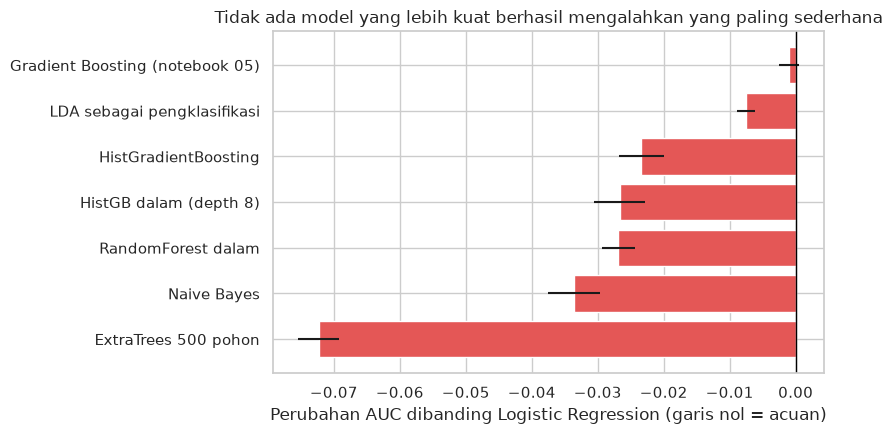

In [10]:
ringkas = pd.DataFrame(hasil_kuat).sort_values("AUC baru", ascending=False)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
warna = ["#4C78A8" if v >= 0 else "#E45756" for v in ringkas["ΔAUC"]]
ax.barh(ringkas.Gagasan, ringkas["ΔAUC"], xerr=ringkas["±AUC"], color=warna)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Perubahan AUC dibanding Logistic Regression (garis nol = acuan)")
ax.set_title("Tidak ada model yang lebih kuat berhasil mengalahkan yang paling sederhana")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

### Hasil: semuanya kalah

**Setiap model yang lebih kuat justru nyata lebih buruk.** Hanya Gradient Boosting
yang mampu mengimbangi AUC — itu pun kalah pada AP.

Ini jawaban atas pertanyaan "apakah kita mentok karena modelnya atau karena datanya?"
Jawabannya: **datanya**. Dengan 15 fitur dan 249 kasus positif, sinyal yang tersedia
sudah habis diperas oleh model linear yang diregularisasi. Menambah kerumitan hanya
menambah overfitting.

## Eksperimen 5 — Apakah Probabilitasnya Bisa Dipercaya?

Untuk alat skrining, ini pertanyaan penting yang sering dilewatkan. Kalau model
berkata "risiko 10%", apakah benar sekitar 10 dari 100 pasien seperti itu terkena
stroke? Angka ini akan dibaca manusia, jadi harus jujur.

In [11]:
cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=SEED)

p_mentah = cross_val_predict(ACUAN(), X, y, cv=cv1, method="predict_proba")[:, 1]
p_iso = cross_val_predict(CalibratedClassifierCV(ACUAN(), method="isotonic", cv=5),
                          X, y, cv=cv1, method="predict_proba")[:, 1]
p_sig = cross_val_predict(CalibratedClassifierCV(ACUAN(), method="sigmoid", cv=5),
                          X, y, cv=cv1, method="predict_proba")[:, 1]

print("Skor Brier (makin KECIL makin jujur):")
for nama, p in [("Tanpa kalibrasi", p_mentah), ("Kalibrasi isotonik", p_iso),
                ("Kalibrasi sigmoid", p_sig)]:
    print(f"  {nama:20} {brier_score_loss(y, p):.5f}")

Skor Brier (makin KECIL makin jujur):
  Tanpa kalibrasi      0.04240
  Kalibrasi isotonik   0.04281
  Kalibrasi sigmoid    0.04242


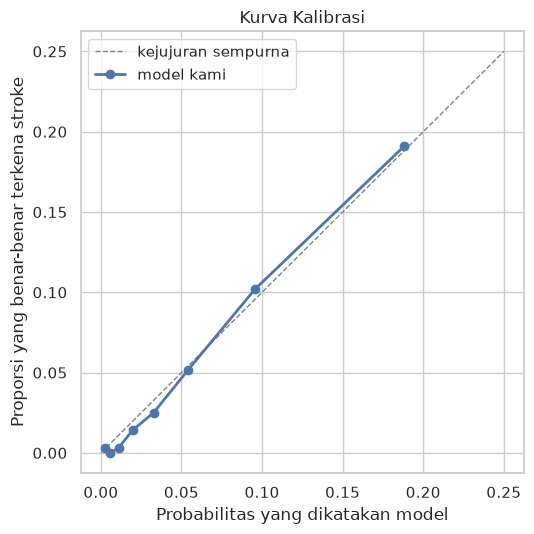

,model bilang,kenyataan
0,0.3,0.3
1,0.6,0.0
2,1.1,0.3
3,2.0,1.4
4,3.3,2.5
5,5.4,5.2
6,9.6,10.2
7,18.8,19.1


In [12]:
frak, rata = calibration_curve(y, p_mentah, n_bins=8, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, .25], [0, .25], "--", color="grey", lw=1, label="kejujuran sempurna")
ax.plot(rata, frak, "o-", color="#4C78A8", lw=2, label="model kami")
ax.set_xlabel("Probabilitas yang dikatakan model")
ax.set_ylabel("Proporsi yang benar-benar terkena stroke")
ax.set_title("Kurva Kalibrasi")
ax.legend(); plt.tight_layout(); plt.show()

pd.DataFrame({"model bilang": (rata * 100).round(1),
              "kenyataan": (frak * 100).round(1)})

### Hasil: sudah jujur sejak awal — jangan diapa-apakan

Kurvanya menempel pada garis kejujuran sempurna. Ketika model berkata 9,6%, kenyataannya
10,2%. Ketika berkata 18,8%, kenyataannya 19,1%.

Dan kedua metode kalibrasi justru **memperburuk** skor Brier.

Masuk akal: Logistic Regression memang dilatih dengan fungsi biaya yang menghasilkan
probabilitas terkalibrasi secara alami. Ini keunggulan yang jarang disebut ketika orang
buru-buru berpindah ke model yang lebih rumit.

## Eksperimen 6 — Memilih Ambang dari Biaya Klinis

Inilah satu-satunya hal yang benar-benar berpengaruh.

Sejauh ini kami memilih ambang dengan aturan "kejar recall ≥ 0,80". Angka 0,80 itu
sebetulnya **tebakan** — tidak ada alasan medis mengapa harus 0,80 dan bukan 0,75.

Cara yang lebih bisa dipertanggungjawabkan: nyatakan berapa kali lebih merugikan
melewatkan pasien stroke dibanding memanggil orang sehat untuk pemeriksaan lanjutan,
lalu biarkan angka itu yang menentukan ambangnya.

In [13]:
def ambang_termurah(y, p, rasio):
    """rasio = berapa kali melewatkan pasien stroke lebih merugikan daripada
    memanggil orang sehat. Kembalikan ambang dengan biaya harapan terkecil."""
    terbaik, biaya_min = 0.5, np.inf
    for t in np.unique(np.round(p, 4)):
        pred = (p >= t).astype(int)
        fn = int(((pred == 0) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        biaya = rasio * fn + fp
        if biaya < biaya_min:
            biaya_min, terbaik = biaya, t
    return terbaik, biaya_min


baris = []
for rasio in [1, 5, 10, 20, 50, 100]:
    t, b = ambang_termurah(y.values, p_mentah, rasio)
    pred = (p_mentah >= t).astype(int)
    baris.append({
        "Rugi FN : FP": f"{rasio} : 1", "Ambang": round(t, 4),
        "recall": round(recall_score(y, pred), 3),
        "precision": round(precision_score(y, pred, zero_division=0), 3),
        "ditandai %": round(100 * pred.mean(), 1),
        "biaya total": int(b),
    })

pd.DataFrame(baris)

,Rugi FN : FP,Ambang,recall,precision,ditandai %,biaya total
0,1 : 1,0.3887,0.008,0.500,0.1,249
1,5 : 1,0.1669,0.317,0.225,6.9,1122
2,10 : 1,0.0863,0.687,0.166,20.1,1638
3,20 : 1,0.0542,0.831,0.131,30.9,2212
4,50 : 1,0.0351,0.920,0.108,41.7,2900
5,100 : 1,0.0208,0.972,0.087,54.7,3255


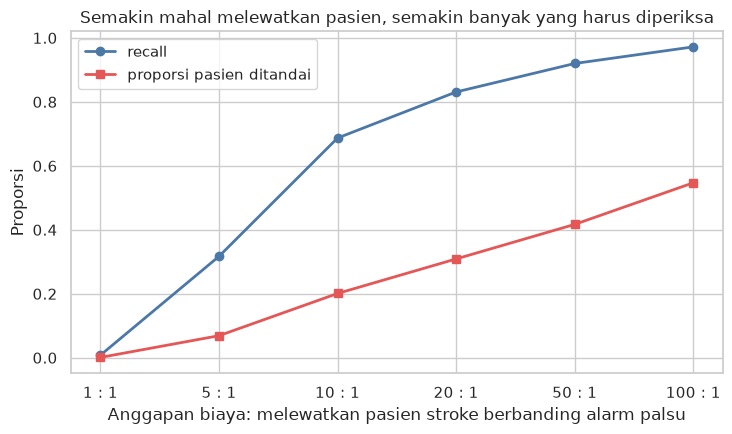

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
t = pd.DataFrame(baris)
ax.plot(range(len(t)), t["recall"], "o-", label="recall", color="#4C78A8", lw=2)
ax.plot(range(len(t)), t["ditandai %"] / 100, "s-", label="proporsi pasien ditandai",
        color="#E45756", lw=2)
ax.set_xticks(range(len(t))); ax.set_xticklabels(t["Rugi FN : FP"])
ax.set_xlabel("Anggapan biaya: melewatkan pasien stroke berbanding alarm palsu")
ax.set_ylabel("Proporsi")
ax.set_title("Semakin mahal melewatkan pasien, semakin banyak yang harus diperiksa")
ax.legend(); plt.tight_layout(); plt.show()

### Hasil: berhasil — dan menjelaskan pilihan kami sebelumnya

Perhatikan baris **20 : 1**. Ambang optimalnya 0,054, dengan recall 0,831.

Bandingkan dengan notebook `05`: ambang yang kami pilih di sana adalah **0,053**,
dengan target recall 0,80.

Nyaris identik. Artinya aturan "kejar recall 0,80" yang tampak sewenang-wenang itu
sebenarnya **menyembunyikan anggapan bahwa melewatkan pasien stroke 20 kali lebih
merugikan daripada satu alarm palsu.**

Kami tidak sadar sedang membuat anggapan itu. Sekarang anggapannya terbuka, bisa
diperdebatkan, dan bisa diubah oleh pihak rumah sakit sesuai kapasitas mereka. Itu
kemajuan yang nyata — bukan pada angkanya, melainkan pada kejujuran penalarannya.

## Kesimpulan

### Rekapitulasi tujuh gagasan

| Gagasan | Hasil |
|---|---|
| Rekayasa fitur medis (7 macam) | gagal — hanya usia kuadrat lolos, besarnya sepele |
| Tujuh cara menyeimbangkan kelas | **merugikan** — semuanya menurunkan AUC secara nyata |
| Penggabungan model (voting) | gagal — perubahan di dalam derau |
| Model yang lebih kuat (6 macam) | **merugikan** — semuanya nyata lebih buruk |
| Kalibrasi probabilitas | tidak perlu — sudah jujur sejak awal |
| Membuang pasien anak-anak | AUC turun, AP sedikit naik — bukan peningkatan |
| **Ambang berbasis biaya klinis** | **berhasil** — mengubah tebakan jadi keputusan beralasan |

### Tiga pelajaran

**1. Sederhana menang, dan itu bukan kebetulan.** Dengan 249 kasus positif dan 15 fitur,
sinyal yang tersedia sudah habis diperas Logistic Regression yang diregularisasi.
Menambah kerumitan hanya menambah overfitting. Batasnya ada pada data, bukan pada model.

**2. Nyata secara statistik ≠ berarti secara praktis.** Dengan 125 lipatan, perbedaan
sekecil 0,002 pun lolos uji statistik. Pertanyaan berikutnya harus selalu: apakah
besarnya cukup untuk mengubah keputusan?

**3. Yang paling berpengaruh bukan modelnya, melainkan pilihan ambangnya.** Dan pilihan
itu bukan persoalan teknis — ia persoalan kebijakan tentang berapa harga pasien yang
terlewat. Tugas kami adalah membuat anggapan itu terlihat, bukan menyembunyikannya
di balik angka 0,80 yang tampak ilmiah.

### Catatan untuk laporan

Sebagian besar isi notebook ini adalah **hasil negatif**. Itu disengaja. Penelitian
yang hanya melaporkan apa yang berhasil membuat pembaca berikutnya mengulangi jalan
buntu yang sama. Tujuh jalan buntu yang terdokumentasi di sini punya nilainya sendiri.